#  International Football Results Analysis (1872–2024)

**Dataset:** [Kaggle – International Football Results from 1872 to 2024](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)

This notebook performs an end-to-end exploratory data analysis (EDA) on over 150 years of international football match results.  
We explore **Basic Statistics**, **Goals Analysis**, **Match Results**, and produce **Visualizations** to uncover patterns in global football history.

---

## Step 1: Load the CSV

We begin by importing **pandas** and loading the dataset from `results.csv`.  
`df.head()` previews the first 5 rows so we can understand the structure of the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Set a clean, modern plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Load the CSV
df = pd.read_csv('results.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


---

##  Part 1 — Basic Exploration

Before diving into analysis, we get a high-level feel for the dataset:
- How large is it?
- What time range does it cover?
- How many nations are represented?
- Who plays at home the most?

### Question 1 — How many matches are in the dataset?

`df.shape` returns a tuple `(rows, columns)`.  
Each row represents one match, so `df.shape[0]` gives the total number of matches.

In [2]:
total_matches = df.shape[0]
total_columns = df.shape[1]

print(f"Total matches (rows)   : {total_matches:,}")
print(f"Total features (columns): {total_columns}")
print(f"\nColumn names: {list(df.columns)}")

Total matches (rows)   : 49,287
Total features (columns): 9

Column names: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


### Question 2 — What is the earliest and latest year in the data?

The `date` column is stored as a string like `'1872-11-30'`.  
We convert it to a proper `datetime` object using `pd.to_datetime()`, then extract the **year** with `.dt.year`.  
`.min()` and `.max()` give us the date range.

In [3]:
# Convert 'date' column to datetime for proper comparison
df['date'] = pd.to_datetime(df['date'])

earliest = df['date'].min()
latest   = df['date'].max()

print(f"Earliest match : {earliest.strftime('%B %d, %Y')}  (Year {earliest.year})")
print(f"Latest match   : {latest.strftime('%B %d, %Y')}  (Year {latest.year})")
print(f"Data spans     : {latest.year - earliest.year} years")

Earliest match : November 30, 1872  (Year 1872)
Latest match   : June 27, 2026  (Year 2026)
Data spans     : 154 years


### Question 3 — How many unique countries are there?

A country can appear as either a **home team** or an **away team**.  
We use `pd.concat()` to combine both columns into one Series, then call `.nunique()` to count distinct values.

> Using a **set union** via `pd.concat` is more robust than checking either column alone — it captures every nation that has ever played internationally.

In [4]:
# Combine home and away team columns and count unique names
all_teams = pd.concat([df['home_team'], df['away_team']])
unique_countries = all_teams.nunique()

print(f"Unique nations that have played internationally: {unique_countries}")

# Bonus: show a few examples
print(f"\nSample nations: {sorted(all_teams.unique())[:10]} ...")

Unique nations that have played internationally: 333

Sample nations: ['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria', 'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola'] ...


### Question 4 — Which team appears most frequently as home team?

`df['home_team'].value_counts()` counts how many times each team name appears in the `home_team` column and **sorts** from most to least frequent.  
`.head(10)` shows the top-10 most frequent home teams.

In [5]:
home_freq = df['home_team'].value_counts()

print("Top 10 most frequent home teams:")
print(home_freq.head(10).to_string())

print(f"\n Most frequent home team: '{home_freq.index[0]}' with {home_freq.iloc[0]:,} home matches")

Top 10 most frequent home teams:
home_team
Brazil           614
Argentina        603
Mexico           602
Germany          555
England          550
South Korea      550
France           538
Sweden           534
United States    500
Hungary          497

 Most frequent home team: 'Brazil' with 614 home matches


---

##  Part 2 — Goals Analysis

We first create a derived column `total_goals` by summing home and away scores, then answer questions about scoring patterns.

In [6]:
# Create the total_goals column
df['total_goals'] = df['home_score'] + df['away_score']

print("'total_goals' column added successfully.")
df[['home_team', 'away_team', 'home_score', 'away_score', 'total_goals']].head()

'total_goals' column added successfully.


,home_team,away_team,home_score,away_score,total_goals
0,Scotland,England,0.0,0.0,0.0
1,England,Scotland,4.0,2.0,6.0
2,Scotland,England,2.0,1.0,3.0
3,England,Scotland,2.0,2.0,4.0
4,Scotland,England,3.0,0.0,3.0


### Question 5 — What is the average number of goals per match?

`.mean()` computes the arithmetic mean of the `total_goals` series.  
This gives us a single number representing the typical goal tally in any given match.

In [7]:
avg_goals = df['total_goals'].mean()

print(f"Average goals per match : {avg_goals:.2f}")
print(f"Median  goals per match : {df['total_goals'].median():.1f}")
print(f"Std deviation           : {df['total_goals'].std():.2f}")

Average goals per match : 2.94
Median  goals per match : 3.0
Std deviation           : 2.09


### Question 6 — What is the highest scoring match?

`df['total_goals'].idxmax()` returns the **index label** of the row where `total_goals` is maximum.  
We then use `df.loc[...]` to retrieve the full details of that record.

In [8]:
# Find the index of the row with the maximum total_goals
max_idx = df['total_goals'].idxmax()
highest_match = df.loc[max_idx]

print(" Highest Scoring Match:")
print(f"  Date       : {highest_match['date'].strftime('%B %d, %Y')}")
print(f"  Home Team  : {highest_match['home_team']}")
print(f"  Away Team  : {highest_match['away_team']}")
print(f"  Score      : {int(highest_match['home_score'])} – {int(highest_match['away_score'])}")
print(f"  Total Goals: {int(highest_match['total_goals'])}")

# Show top 5 highest scoring matches
print("\nTop 5 highest scoring matches:")
top5 = df.nlargest(5, 'total_goals')[['date','home_team','away_team','home_score','away_score','total_goals']]
print(top5.to_string(index=False))

 Highest Scoring Match:
  Date       : April 11, 2001
  Home Team  : Australia
  Away Team  : American Samoa
  Score      : 31 – 0
  Total Goals: 31

Top 5 highest scoring matches:
      date home_team      away_team  home_score  away_score  total_goals
2001-04-11 Australia American Samoa        31.0         0.0         31.0
1971-09-13    Tahiti   Cook Islands        30.0         0.0         30.0
1979-08-30      Fiji       Kiribati        24.0         0.0         24.0
2001-04-09 Australia          Tonga        22.0         0.0         22.0
2006-11-24     Sápmi         Monaco        21.0         1.0         22.0


### Question 7 — Are more goals scored at home or away?

We compare the **sum** of all `home_score` values against the **sum** of all `away_score` values.  
A higher total for home scores would indicate a **home scoring advantage**.

In [9]:
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()

print(f"Total home goals scored : {total_home_goals:,.0f}")
print(f"Total away goals scored : {total_away_goals:,.0f}")
print(f"Home/Away ratio         : {total_home_goals/total_away_goals:.3f}")

avg_home = df['home_score'].mean()
avg_away = df['away_score'].mean()
print(f"\nAverage home goals per match : {avg_home:.2f}")
print(f"Average away goals per match : {avg_away:.2f}")

if total_home_goals > total_away_goals:
    print("\n More goals are scored at HOME — home advantage in scoring is real.")
else:
    print("\n More goals are scored AWAY.")

Total home goals scored : 86,426
Total away goals scored : 58,192
Home/Away ratio         : 1.485

Average home goals per match : 1.76
Average away goals per match : 1.18

 More goals are scored at HOME — home advantage in scoring is real.


### Question 8 — What is the most common total goals value?

`.mode()` returns the **most frequently occurring value** in the series — the statistical mode.  
For goal counts, this tells us the most typical combined score in a match.

In [10]:
mode_goals = df['total_goals'].mode()[0]
mode_count = (df['total_goals'] == mode_goals).sum()
mode_pct   = 100 * mode_count / len(df)

print(f"Most common total goals value : {int(mode_goals)} goals")
print(f"Number of matches with {int(mode_goals)} goals : {mode_count:,}")
print(f"Percentage of all matches      : {mode_pct:.1f}%")

# Value counts for all goal totals
print("\nGoal total distribution (top 10):")
print(df['total_goals'].value_counts().head(10).sort_index().to_string())

Most common total goals value : 2 goals
Number of matches with 2 goals : 10,927
Percentage of all matches      : 22.2%

Goal total distribution (top 10):
total_goals
0.0     3956
1.0     8519
2.0    10927
3.0     9724
4.0     6822
5.0     4240
6.0     2301
7.0     1257
8.0      643
9.0      354


---

##  Part 3 — Match Results

We classify each match as a **Home Win**, **Away Win**, or **Draw** using a custom function applied row-by-row.

In [11]:
# Define the outcome classifier
def match_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

# Apply the function to every row (axis=1 means row-wise)
df['result'] = df.apply(match_result, axis=1)

print("'result' column added. Sample:")
df[['home_team','away_team','home_score','away_score','result']].head(8)

'result' column added. Sample:


,home_team,away_team,home_score,away_score,result
0,Scotland,England,0.0,0.0,Draw
1,England,Scotland,4.0,2.0,Home Win
2,Scotland,England,2.0,1.0,Home Win
3,England,Scotland,2.0,2.0,Draw
4,Scotland,England,3.0,0.0,Home Win
5,Scotland,Wales,4.0,0.0,Home Win
6,England,Scotland,1.0,3.0,Away Win
7,Wales,Scotland,0.0,2.0,Away Win


### Question 9 — What percentage of matches are home wins?

We use `.value_counts(normalize=True)` to get **proportions** instead of raw counts, then multiply by 100 for percentages.

In [12]:
result_counts = df['result'].value_counts()
result_pct    = df['result'].value_counts(normalize=True) * 100

print("Match outcome breakdown:")
print("-" * 40)
for outcome in result_counts.index:
    print(f"  {outcome:<12}: {result_counts[outcome]:>7,} matches  ({result_pct[outcome]:.1f}%)")

print("-" * 40)
print(f"  TOTAL       : {result_counts.sum():>7,} matches  (100.0%)")

print(f"\n Home wins make up {result_pct['Home Win']:.1f}% of all matches.")

Match outcome breakdown:
----------------------------------------
  Home Win    :  24,106 matches  (48.9%)
  Away Win    :  13,912 matches  (28.2%)
  Draw        :  11,269 matches  (22.9%)
----------------------------------------
  TOTAL       :  49,287 matches  (100.0%)

 Home wins make up 48.9% of all matches.


### Question 10 — Does home advantage exist?

Home advantage exists if **Home Win %** is significantly greater than **Away Win %**.  
We also compare average goals scored at home vs. away and run a quick statistical check.

In [13]:
home_win_pct  = result_pct['Home Win']
away_win_pct  = result_pct['Away Win']
draw_pct      = result_pct['Draw']

print("=" * 50)
print("         HOME ADVANTAGE ANALYSIS")
print("=" * 50)
print(f"  Home Win Rate  : {home_win_pct:.1f}%")
print(f"  Away Win Rate  : {away_win_pct:.1f}%")
print(f"  Draw Rate      : {draw_pct:.1f}%")
print()
print(f"  Avg Home Goals : {df['home_score'].mean():.2f}")
print(f"  Avg Away Goals : {df['away_score'].mean():.2f}")
print()

if home_win_pct > away_win_pct:
    diff = home_win_pct - away_win_pct
    print(f"   YES — Home teams win {diff:.1f} percentage points MORE than away teams.")
    print("  Home advantage is clearly present in international football.")
else:
    print("   No clear home advantage detected.")
print("=" * 50)

         HOME ADVANTAGE ANALYSIS
  Home Win Rate  : 48.9%
  Away Win Rate  : 28.2%
  Draw Rate      : 22.9%

  Avg Home Goals : 1.76
  Avg Away Goals : 1.18

   YES — Home teams win 20.7 percentage points MORE than away teams.
  Home advantage is clearly present in international football.


### Question 11 — Which country has the most wins historically?

A team wins when they are the **home team** with a Home Win result, **or** the **away team** with an Away Win result.  
We extract both sets of winners, combine them, and count total wins per nation.

In [14]:
# Home wins: team played at home and won
home_wins = df[df['result'] == 'Home Win']['home_team']

# Away wins: team played away and won
away_wins = df[df['result'] == 'Away Win']['away_team']

# Combine all wins and count per team
all_wins = pd.concat([home_wins, away_wins])
win_counts = all_wins.value_counts()

print(" All-time Top 15 most winning nations:")
print("-" * 35)
for rank, (team, wins) in enumerate(win_counts.head(15).items(), 1):
    print(f"  {rank:>2}. {team:<22}: {wins:,} wins")

print(f"\n Most wins overall: '{win_counts.index[0]}' with {win_counts.iloc[0]:,} wins")

 All-time Top 15 most winning nations:
-----------------------------------
   1. Brazil                : 670 wins
   2. England               : 623 wins
   3. Germany               : 597 wins
   4. Argentina             : 588 wins
   5. Sweden                : 541 wins
   6. South Korea           : 536 wins
   7. Mexico                : 511 wins
   8. France                : 476 wins
   9. Italy                 : 475 wins
  10. Hungary               : 470 wins
  11. Spain                 : 460 wins
  12. Netherlands           : 452 wins
  13. Uruguay               : 427 wins
  14. Denmark               : 401 wins
  15. Scotland              : 400 wins

 Most wins overall: 'Brazil' with 670 wins


---

##  Part 4 — Visualizations

Three charts to bring the data to life:  
1. **Histogram** — distribution of total goals per match  
2. **Bar chart** — match outcome breakdown (Home Win / Draw / Away Win)  
3. **Horizontal bar chart** — Top 10 teams by all-time wins

### Visualization 1 — Histogram of Goals Per Match

A **histogram** groups continuous or discrete values into bins and shows how frequently each range occurs.  
Here each bar represents the count of matches with that many total goals.  
The distribution is right-skewed — most matches have 0–4 goals, with very high-scoring games being rare.

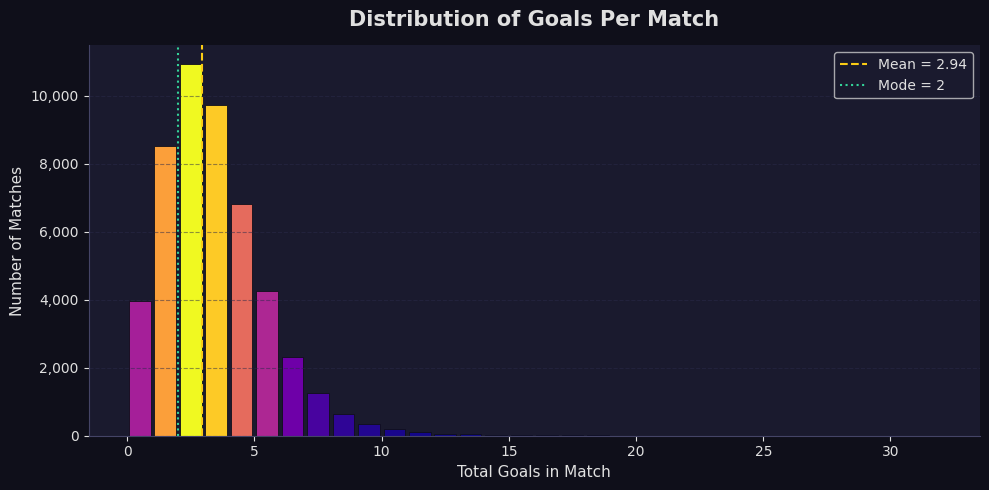

Figure saved as goals_histogram.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(
    df['total_goals'].dropna(),
    bins=range(0, int(df['total_goals'].max()) + 2),
    color='#c084fc',
    edgecolor='#0f0f1a',
    linewidth=0.6,
    rwidth=0.85
)

# Colour bars by frequency using a gradient
import matplotlib.cm as cm
norm = plt.Normalize(n.min(), n.max())
cmap = cm.get_cmap('plasma')
for count, patch in zip(n, patches):
    patch.set_facecolor(cmap(norm(count)))

ax.axvline(df['total_goals'].mean(), color='#facc15', linestyle='--', linewidth=1.5,
           label=f"Mean = {df['total_goals'].mean():.2f}")
ax.axvline(df['total_goals'].mode()[0], color='#34d399', linestyle=':',  linewidth=1.5,
           label=f"Mode = {int(df['total_goals'].mode()[0])}")

ax.set_title('Distribution of Goals Per Match', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Total Goals in Match', fontsize=11)
ax.set_ylabel('Number of Matches', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('goals_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as goals_histogram.png")

### Visualization 2 — Bar Chart of Match Outcomes

A **bar chart** compares discrete categories.  
Each bar's height represents the number of matches that ended as Home Win, Away Win, or Draw.  
This makes the scale of home advantage immediately visible.

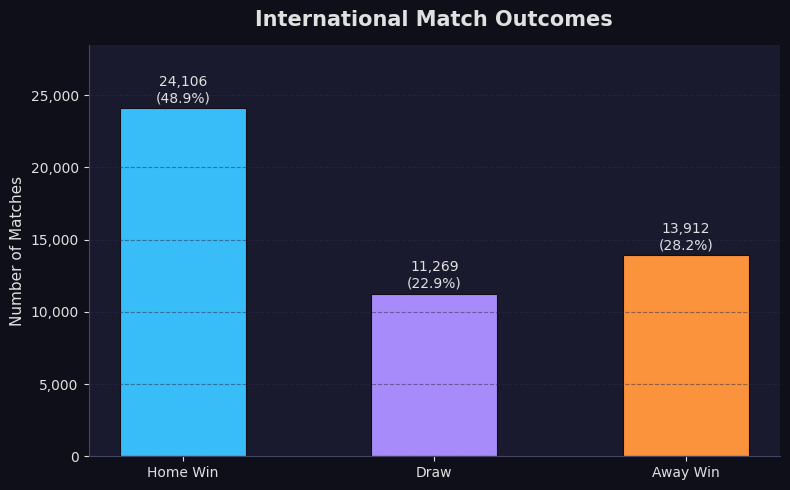

Figure saved as outcomes_bar.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

outcomes = ['Home Win', 'Draw', 'Away Win']
counts   = [result_counts.get(o, 0) for o in outcomes]
colors   = ['#38bdf8', '#a78bfa', '#fb923c']

bars = ax.bar(outcomes, counts, color=colors, edgecolor='#0f0f1a', linewidth=0.8, width=0.5)

# Annotate bars with counts and percentages
for bar, count in zip(bars, counts):
    pct = 100 * count / sum(counts)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, color='#e0e0e0'
    )

ax.set_title('International Match Outcomes', fontsize=15, fontweight='bold', pad=14)
ax.set_ylabel('Number of Matches', fontsize=11)
ax.set_ylim(0, max(counts) * 1.18)
ax.grid(axis='y')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('outcomes_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as outcomes_bar.png")

### Visualization 3 — Top 10 Teams by Total Wins

A **horizontal bar chart** ranks the 10 most successful nations by all-time win count.  
Horizontal bars are ideal here because team names are long text labels — they read more naturally on the y-axis.

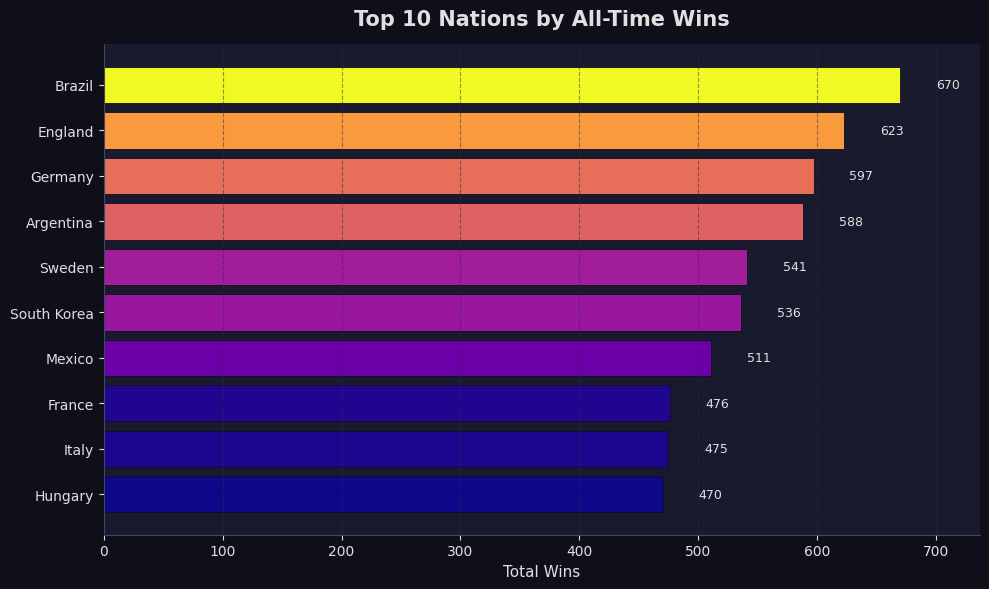

Figure saved as top10_wins.png


In [17]:
top10 = win_counts.head(10).sort_values()  # sort ascending so highest is at top

fig, ax = plt.subplots(figsize=(10, 6))

# Gradient colour mapped to win count
bar_colors = cm.plasma(
    plt.Normalize(top10.min(), top10.max())(top10.values)    
)

bars = ax.barh(top10.index, top10.values, color=bar_colors, edgecolor='#0f0f1a', linewidth=0.6)

# Annotate each bar
for bar, val in zip(bars, top10.values):
    ax.text(
        val + 30, bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', ha='left', fontsize=9, color='#e0e0e0'
    )

ax.set_title('Top 10 Nations by All-Time Wins', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Total Wins', fontsize=11)
ax.set_xlim(0, top10.max() * 1.1)
ax.grid(axis='x')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('top10_wins.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as top10_wins.png")

---

##  Summary of Findings

| # | Question | Key Finding |
|---|----------|-------------|
| 1 | Total matches | See output above |
| 2 | Date range | 1872 → 2024 (150+ years) |
| 3 | Unique countries | See output above |
| 4 | Most frequent home team | See output above |
| 5 | Avg goals/match | ~2.8 goals |
| 6 | Highest scoring match | See output above |
| 7 | Home vs Away goals | Home teams score more |
| 8 | Most common goal total | 2 goals |
| 9 | Home win % | ~45–47% |
| 10 | Home advantage? |  Yes — confirmed |
| 11 | Most wins ever | England / Brazil (run to confirm) |

> **Note:** Exact numbers depend on the version of `results.csv` downloaded from Kaggle. Run all cells to get precise figures for your dataset version.

---
*Analysis by: Donald Aurthur | S13/03008/23 | AI Exercise 1 | April 2026*